# System Design Flow Verifier - LangGraph Multi-Agent Review

## Scenario
This notebook verifies and improves a textual system-design flow by sending it through specialized reviewer agents for Security, Backend, and Performance. A FlowEditor agent rewrites the flow, a Summarization agent prepares the final answer, real search tools provide external context, and a Human-in-the-Loop interruption is used before the final output.

## How agents communicate through state
The graph uses a shared state object so each node can read the current candidate flow and publish only its own delta. The three reviewer agents run in parallel, so `review_results` remains merge-safe and each reviewer always overwrites only its own entry.

### State fields and what they contain
- `current_flow`: the candidate flow currently under review
- `review_results`: latest structured review per reviewer for the current pass
- `loop_count`: number of automated improve-and-rerun cycles already used
- `final_output`: final summary prepared by the summarization node

### Which agent touches which fields
- Security, Backend, and Performance read `current_flow`, use checkpointed agent history, and write only `review_results`
- The review router reads `review_results` and logs only (no state updates)
- FlowEditor reads `current_flow` and `review_results`, uses its own checkpointed agent history, and writes `current_flow`, `loop_count`, and (when needed) a reset for the Human review entry in `review_results`
- Human Review reads `current_flow`, `review_results`, and `loop_count`, then returns a `Command` that routes to either FlowEditor or Summarization
- Summarization reads `current_flow` and `review_results`, uses its own checkpointed agent history, and writes `final_output`

## Scope for this iteration
This notebook now implements the first real-agent iteration: GPT-backed reviewer, FlowEditor, and summarization agents run inside the LangGraph workflow, the tools are invoked by the agents through LangChain tool calling, checkpointed agent threads preserve history across loops and resumes, and the Google Colab helper cells are intentionally kept at the end of the notebook.

## Reference patterns reused
- Interrupts notebook: interrupt, InMemorySaver, checkpoint inspection, state-history inspection, graph visualization helpers
- Simple Graphs Part 2: conditional routing in StateGraph
- Checkpointers Part 1: execution with thread-scoped checkpoints


In [1]:
%pip install -q langgraph langchain langchain-openai langchain-community python-dotenv ddgs youtube-search

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import importlib
from pathlib import Path
from dotenv import dotenv_values

PROJECT_DIR = Path.cwd()
ENV_PATH = PROJECT_DIR / '.env'
env_values = dotenv_values(ENV_PATH)

openai_key = str(env_values.get('OPENAI_KEY') or '').strip()
try:
    colab_module = importlib.import_module('google.colab')
except ImportError:
    colab_module = None

if colab_module is not None:
    colab_key = str(colab_module.userdata.get('OPENAI_KEY') or '').strip()
    if colab_key:
        openai_key = colab_key
        print('Loaded OPENAI_KEY from Google Colab secrets.')
    else:
        print('google.colab detected but OPENAI_KEY secret is missing. Falling back to .env.')
else:
    print('google.colab is not available. Using .env file.')

if not openai_key:
    raise RuntimeError('OPENAI_KEY is not set. Add it to the local .env or Colab secrets before running agent cells.')

print(f'Using environment file: {ENV_PATH}')
print(f'OPENAI_KEY present: {bool(openai_key)}')

google.colab is not available. Using .env file.
Using environment file: d:\CodingProjects\SoftUniAgentWorkflows\LangGraph-simple-project\.env
OPENAI_KEY present: True


In [3]:
import json
import logging
import operator
import sys
from datetime import datetime, timezone
from typing import Annotated, Any, Literal, TypedDict
from uuid import uuid4

from IPython.display import HTML, Image, display
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.tools import YouTubeSearchTool
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.runnables import Runnable, RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.base import BaseCheckpointSaver
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, StateGraph
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command, Interrupt, interrupt
from pydantic import BaseModel, Field

def merge_review_results(
    a: list[dict[str, dict[str, str]]],
    b: list[dict[str, dict[str, str]]],
) -> list[dict[str, dict[str, str]]]:
    merged = [dict(step) for step in a]
    for incoming_step in b:
        if not incoming_step:
            continue
        incoming_copy = dict(incoming_step)
        if not merged:
            merged.append(incoming_copy)
            continue
        if set(merged[-1]).intersection(incoming_copy):
            merged.append(incoming_copy)
        else:
            merged[-1] = {**merged[-1], **incoming_copy}
    return merged

class UtcMillisFormatter(logging.Formatter):
    def formatTime(self, record, _datefmt=None):
        _ = _datefmt
        timestamp = datetime.fromtimestamp(record.created, timezone.utc)
        return timestamp.isoformat(timespec='milliseconds').replace('+00:00', 'Z')

logger = logging.getLogger('system_design_flow_verifier')
logger.setLevel(logging.INFO)
logger.handlers.clear()
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(UtcMillisFormatter('%(asctime)-24s --- %(message)s'))
logger.addHandler(stream_handler)
logger.propagate = False

def get_active_reviews(state) -> list[dict[str, str]]:
    review_history = state.get('review_results', [])
    if not review_history:
        return []
    latest_reviews = review_history[-1]
    return [
        review
        for review in latest_reviews.values()
        if review.get('status') == 'reject'
    ]

def stringify_content(content: Any) -> str:
    if isinstance(content, str):
        return content
    return json.dumps(content, ensure_ascii=True)

def limit_words(text: str, max_words: int = 200) -> str:
    words = text.split()
    return ' '.join(words[:max_words])

def build_chat_model(model_name: str) -> ChatOpenAI:
    return ChatOpenAI(
        model=model_name,
        api_key=openai_key,
        timeout=120,
        max_retries=2,
    )

def summarize_state_for_debug(state: dict[str, Any]) -> dict[str, Any]:
    return dict(state)

def format_state_lines(state: dict[str, Any]) -> list[str]:
    serialized = json.dumps(summarize_state_for_debug(state), ensure_ascii=True, indent=2)
    return serialized.splitlines()

def print_interrupts(interrupts: list[Interrupt]) -> None:
    for item in interrupts:
        display(HTML(f'<div style="border: 1px dashed red; margin: 5px; padding: 10px; white-space: pre-wrap;">{item.value}</div>'))

def display_graph(runnable: Runnable) -> None:
    try:
        display(Image(data=runnable.get_graph().draw_mermaid_png(), format='png'))
    except Exception as exc:
        logger.info(f'PNG graph rendering failed: {exc}')
        logger.info('ASCII fallback:')
        runnable.get_graph().print_ascii()

def explore_checkpoints(checkpointer: BaseCheckpointSaver, config: RunnableConfig) -> None:
    checkpoints = list(checkpointer.list(config))
    logger.info(f'There are {len(checkpoints)} checkpoints in total:')
    for checkpoint in reversed(checkpoints):
        for line in str(checkpoint).splitlines():
            logger.info(line)

def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig) -> None:
    state_history = list(compiled_state_graph.get_state_history(config))
    for snapshot in reversed(state_history):
        logger.info(f"Step: {snapshot.metadata['step']}")
        logger.info('Current state:')
        for line in format_state_lines(snapshot.values):
            logger.info(line)
        logger.info(f'Next: {snapshot.next}')
        logger.info('')

def show_state(snapshot) -> None:
    logger.info(f'Interrupt count: {len(snapshot.interrupts)}')
    for line in format_state_lines(snapshot.values):
        logger.info(line)

def build_agent_config(workflow_config: RunnableConfig, agent_name: str) -> RunnableConfig:
    _ = agent_name
    workflow_thread_id = workflow_config['configurable']['thread_id']
    return {'configurable': {'thread_id': workflow_thread_id}}

def get_agent_messages(agent: Runnable, agent_config: RunnableConfig) -> list[BaseMessage]:
    try:
        snapshot = agent.get_state(agent_config)
        return snapshot.values.get('messages', [])
    except Exception:
        return []

def extract_tool_call_names(messages: list[BaseMessage]) -> list[str]:
    tool_names: list[str] = []
    for message in messages:
        if not isinstance(message, AIMessage):
            continue
        for tool_call in message.tool_calls:
            name = tool_call.get('name') if isinstance(tool_call, dict) else getattr(tool_call, 'name', '')
            if name:
                tool_names.append(name)
    return tool_names

AGENT_RUNNABLES: dict[str, Runnable] = {}

def show_agent_history(agent_name: str, workflow_config: RunnableConfig) -> None:
    agent = AGENT_RUNNABLES[agent_name]
    messages = get_agent_messages(agent, build_agent_config(workflow_config, agent_name))
    logger.info(f'Agent history for {agent_name}: {len(messages)} messages')
    for message in messages:
        logger.info(f'[{message.type}] {stringify_content(message.content)}')


In [4]:
WEB_SEARCH_TOOL = DuckDuckGoSearchResults(
    name='web_search',
    description='Search current architecture and system-design best practices. Input should be a focused search query.',
    num_results=4,
    output_format='list',
)
YOUTUBE_SEARCH_TOOL = YouTubeSearchTool()
AGENT_CHECKPOINTER = InMemorySaver()

In [5]:
class WorkflowState(TypedDict):
    flow_history: Annotated[list[str], operator.add]
    review_results: Annotated[list[dict[str, dict[str, str]]], merge_review_results]
    loop_count: int
    final_output: str


In [6]:
class ReviewDecision(BaseModel):
    status: Literal['accept', 'reject'] = Field(description='accept when the flow is good enough for this reviewer, otherwise reject.')
    comment: str = Field(description='Short reviewer comment. Must be empty when status is accept.')
    recommendation: str = Field(description='Exactly one major action-oriented recommendation. Must be empty when status is accept.')

class ImprovementResult(BaseModel):
    updated_flow: str = Field(description='The rewritten system-design flow as plain text. Up to 50 words')
    change_summary: str = Field(description='A short explanation of what changed and why. Up to 50 words.')

class SummaryResult(BaseModel):
    improvements_summary: str = Field(description='A concise summary of the accepted improvements in 200 words or fewer.')
    youtube_links: list[str] = Field(description='One YouTube link per applied change.')

REVIEWER_PROMPTS = {
    'Security': """
    You are the Security reviewer for a textual system-design flow. Use the supplied web-search findings as evidence.
    You must call the web_search tool before returning your final decision.
    Return exactly one JSON object with status, comment, recommendation. Status must be accept or reject.
    If status is accept, comment and recommendation must both be empty strings. If status is reject, both must contain values.
    Ignore style and minor details. Focus only on the highest-impact security gap. 
    <must>FOCUS ONLY ON SECURITY ISSUES!</must>
    Each response must be with less than 100 words.
    """,
    'Backend': """
    You are the Backend reviewer for a textual system-design flow. Use the supplied web-search findings as evidence. 
    You must call the web_search tool before returning your final decision. 
    Return exactly one JSON object with status, comment, recommendation. Status must be accept or reject. 
    If status is accept, comment and recommendation must both be empty strings. If status is reject, both must contain values. 
    Focus on correctness, durability, and service coordination. 
    <must>FOCUS ONLY ON BACKEND ISSUES RELATED TO LOGIC, CORNER CASES, AND DATA INTEGRITY!</must>
    Each response must be with less than 100 words.
    """,
    'Performance': """
    You are the Performance reviewer for a textual system-design flow. Use the supplied web-search findings as evidence.
    You must call the web_search tool before returning your final decision.
    Return exactly one JSON object with status, comment, recommendation. Status must be accept or reject.
    If status is accept, comment and recommendation must both be empty strings. If status is reject, both must contain values.
    Ignore style and minor details. Focus on the highest-impact latency or throughput issue. 
    <must>FOCUS ONLY ON PERFORMANCE ISSUES RELATED TO LATENCY AND THROUGHPUT!</must>
    Each response must be with less than 100 words.
    """,
}
FLOW_EDITOR_PROMPT = """You are the FlowEditor agent. Rewrite the current flow using reviewer comments and optional human feedback. 
Keep the answer concrete and implementation-oriented. Return the result through structured fields updated_flow and change_summary.
"""

SUMMARIZER_PROMPT = """You are the Summarization agent. Use the current flow and latest reviews to produce a concise final improvement summary under 200 words.
You must call the youtube_search tool once per meaningful improvement topic. The tool input format is '<topic>, 1'. Return exactly one JSON object with keys improvements_summary and youtube_links.
Keep the flow unchanged. Focus on what was improved and why it matters.
"""

REVIEWER_AGENTS = {
    reviewer: create_agent(
        model=build_chat_model('gpt-5-mini'),
        tools=[WEB_SEARCH_TOOL],
        system_prompt=prompt,
        response_format=ReviewDecision,
        checkpointer=AGENT_CHECKPOINTER,
        name=f'{reviewer.lower()}_review_agent',
    )
    for reviewer, prompt in REVIEWER_PROMPTS.items()
}
FLOW_EDITOR_AGENT = create_agent(
    model=build_chat_model('gpt-5-mini'),
    tools=None,
    system_prompt=FLOW_EDITOR_PROMPT,
    response_format=ImprovementResult,
    checkpointer=AGENT_CHECKPOINTER,
    name='flow_editor_agent',
)
SUMMARIZER_AGENT = create_agent(
    model=build_chat_model('gpt-5-nano'),
    tools=[YOUTUBE_SEARCH_TOOL],
    system_prompt=SUMMARIZER_PROMPT,
    response_format=SummaryResult,
    checkpointer=AGENT_CHECKPOINTER,
    name='summarizer_agent',
)
AGENT_RUNNABLES = {**REVIEWER_AGENTS, 'FlowEditor': FLOW_EDITOR_AGENT, 'Summarization': SUMMARIZER_AGENT}

def get_structured_response(agent_result: dict, schema: type[BaseModel]) -> BaseModel:
    structured_response = agent_result.get('structured_response')
    if structured_response is None:
        raise ValueError('Agent did not return structured_response. Check model support for response_format.')
    return schema.model_validate(structured_response)

def validate_review_decision(decision: ReviewDecision) -> ReviewDecision:
    status = decision.status.strip().lower()
    comment = decision.comment.strip()
    recommendation = decision.recommendation.strip()
    if status not in {'accept', 'reject'}:
        raise ValueError(f'Unsupported review status: {decision.status}')
    if status == 'accept' and (comment or recommendation):
        raise ValueError('Accept decisions must have empty comment and recommendation fields.')
    if status == 'reject' and (not comment or not recommendation):
        raise ValueError('Reject decisions must include both comment and recommendation.')
    return ReviewDecision(status=status, comment=comment, recommendation=recommendation)

def build_review(reviewer: str, decision: ReviewDecision) -> dict[str, str]:
    return {
        'reviewer': reviewer,
        'status': decision.status,
        'comment': decision.comment.strip(),
        'recommendation': decision.recommendation.strip(),
    }

def run_reviewer_agent(reviewer: str, state: WorkflowState, config: RunnableConfig) -> ReviewDecision:
    agent = REVIEWER_AGENTS[reviewer]
    agent_config = build_agent_config(config, reviewer)
    previous_messages = get_agent_messages(agent, agent_config)
    proposal = state['flow_history'][-1]
    agent_input = f'Review the new flow proposal: {proposal}'
    agent_result = agent.invoke({'messages': [HumanMessage(content=agent_input)]}, config=agent_config)
    new_messages = agent_result['messages'][len(previous_messages):]
    tool_names = extract_tool_call_names(new_messages)
    for tool_name in tool_names:
        logger.info(f'[{reviewer}][Tool Call] {tool_name}')
    decision = validate_review_decision(get_structured_response(agent_result, ReviewDecision))
    return decision

def security_review(state: WorkflowState, config: RunnableConfig) -> dict:
    logger.info('[Security] node is executing')
    decision = run_reviewer_agent('Security', state, config)
    review = build_review('Security', decision)
    return {
        'review_results': [{'Security': review}],
    }

def backend_review(state: WorkflowState, config: RunnableConfig) -> dict:
    logger.info('[Backend] node is executing')
    decision = run_reviewer_agent('Backend', state, config)
    review = build_review('Backend', decision)
    return {
        'review_results': [{'Backend': review}],
    }

def performance_review(state: WorkflowState, config: RunnableConfig) -> dict:
    logger.info('[Performance] node is executing')
    decision = run_reviewer_agent('Performance', state, config)
    review = build_review('Performance', decision)
    return {
        'review_results': [{'Performance': review}],
    }

def review_router(state: WorkflowState) -> dict:
    active_reviews = get_active_reviews(state)
    logger.info(f'[Review Router] Active major reviews: {len(active_reviews)}')
    return {}


In [7]:
MAX_AUTO_LOOPS = 1

def flow_editor(state: WorkflowState, config: RunnableConfig) -> dict:
    logger.info('[FlowEditor] node is executing')
    active_reviews = get_active_reviews(state)
    reviewer_notes = [
        f"- {review['reviewer']}: {review['recommendation']} (comment: {review['comment']})"
        for review in active_reviews
        if review.get('status') == 'reject'
    ]
    agent_config = build_agent_config(config, 'FlowEditor')
    agent_input = '\n'.join([
        'Current flow:',
        state['flow_history'][-1],
        '',
        'Reviewer comments:',
        '\n'.join(reviewer_notes) if reviewer_notes else '- None.',
        '',
        'Return improved flow.',
    ])
    agent_result = FLOW_EDITOR_AGENT.invoke({'messages': [HumanMessage(content=agent_input)]}, config=agent_config)
    improvement_result = get_structured_response(agent_result, ImprovementResult)
    updated_flow = improvement_result.updated_flow.strip()
    if not updated_flow:
        raise ValueError('FlowEditor returned an empty updated_flow.')
    return {
        'flow_history': [updated_flow],
        'loop_count': state['loop_count'] + 1,
    }

def final_human_approval(state: WorkflowState) -> dict:
    logger.info('[Final Human Approval] node is executing')
    active_reviews = get_active_reviews(state)
    prompt = {
        'reason': 'All automated reviewers accepted the latest flow.',
        'loop_count': state['loop_count'],
        'current_flow': state['flow_history'][-1],
        'pending_reviews': active_reviews,
        'question': "Reply with {'action': 'approve'} to continue, or {'action': 'reject'} to provide a manual final flow.",
    }
    response = interrupt(prompt)

    if isinstance(response, str):
        response = {'action': response}

    action = str(response.get('action', 'reject')).lower().strip()
    if action == 'approve':
        return {
            'review_results': [
                {
                    'HumanApproval': {
                        'reviewer': 'HumanApproval',
                        'status': 'accept',
                        'comment': '',
                        'recommendation': '',
                    }
                }
            ]
        }
    if action == 'reject':
        return {
            'review_results': [
                {
                    'HumanApproval': {
                        'reviewer': 'HumanApproval',
                        'status': 'reject',
                        'comment': 'Human requested manual final flow.',
                        'recommendation': 'Provide a manual final flow.',
                    }
                }
            ]
        }
    raise ValueError(f"Unsupported final human approval action: {action}")

def human_decision(state: WorkflowState) -> dict:
    logger.info('[Human Decision] node is executing')
    prompt = {
        'reason': 'Manual final flow is required.',
        'loop_count': state['loop_count'],
        'current_flow': state['flow_history'][-1],
        'question': "Reply with {'final_flow': '...'} (required).",
    }
    response = interrupt(prompt)

    if isinstance(response, str):
        response = {'final_flow': response}

    final_flow = str(response.get('final_flow', '')).strip()
    if not final_flow:
        raise ValueError('human_decision requires a non-empty final_flow.')

    return {
        'flow_history': [final_flow],
        'review_results': [
            {
                'HumanDecision': {
                    'reviewer': 'HumanDecision',
                    'status': 'accept',
                    'comment': 'Manual final flow provided by human.',
                    'recommendation': '',
                }
            }
        ],
    }

def summarize(state: WorkflowState, config: RunnableConfig) -> dict:
    logger.info('[Summarization] node is executing')
    agent_config = build_agent_config(config, 'Summarization')
    previous_messages = get_agent_messages(SUMMARIZER_AGENT, agent_config)
    review_history = state.get('review_results', [])
    latest_reviews = review_history[-1] if review_history else {}
    review_lines = [
        f"- {name}: status={review.get('status', '')}, recommendation={review.get('recommendation', '')}"
        for name, review in latest_reviews.items()
    ]
    agent_input = '\n'.join([
        'Final flow proposal:',
        state['flow_history'][-1],
        '',
        'Latest review snapshot:',
        '\n'.join(review_lines) if review_lines else '- None.',
        '',
        'Use the youtube_search tool once per meaningful improvement topic. Its input format is <topic>, 1.',
        'Return exactly one JSON object with keys improvements_summary and youtube_links.',
    ])
    agent_result = SUMMARIZER_AGENT.invoke({'messages': [HumanMessage(content=agent_input)]}, config=agent_config)
    new_messages = agent_result['messages'][len(previous_messages):]
    tool_names = extract_tool_call_names(new_messages)
    for tool_name in tool_names:
        logger.info(f'[Tool Call] {tool_name}')
    summary_result = get_structured_response(agent_result, SummaryResult)
    summary = limit_words(summary_result.improvements_summary.strip())
    youtube_links = summary_result.youtube_links
    lines = [
        'Final flow proposal:',
        state['flow_history'][-1],
        '',
        'Improvements summary:',
        summary,
        '',
        'YouTube references:',
    ]
    lines.extend([f'- {link}' for link in youtube_links])

    return {
        'final_output': '\n'.join(lines),
    }

def route_after_reviews(state: WorkflowState) -> str:
    if not get_active_reviews(state):
        return 'final_human_approval'
    if state['loop_count'] < MAX_AUTO_LOOPS:
        return 'flow_editor'
    return 'human_decision'

def route_after_final_human_approval(state: WorkflowState) -> str:
    review_history = state.get('review_results', [])
    latest_reviews = review_history[-1] if review_history else {}
    human_status = latest_reviews.get('HumanApproval', {}).get('status')
    if human_status == 'accept':
        return 'summarize'
    if human_status == 'reject':
        return 'human_decision'
    raise ValueError(f'Unsupported final human approval status: {human_status}')


In [8]:
checkpointer = InMemorySaver()
graph_builder = StateGraph(WorkflowState)
graph_builder.add_node('security_review', security_review)
graph_builder.add_node('backend_review', backend_review)
graph_builder.add_node('performance_review', performance_review)
graph_builder.add_node('review_router', review_router)
graph_builder.add_node('flow_editor', flow_editor)
graph_builder.add_node('final_human_approval', final_human_approval)
graph_builder.add_node('human_decision', human_decision)
graph_builder.add_node('summarize', summarize)

graph_builder.add_edge(START, 'security_review')
graph_builder.add_edge(START, 'backend_review')
graph_builder.add_edge(START, 'performance_review')
graph_builder.add_edge('security_review', 'review_router')
graph_builder.add_edge('backend_review', 'review_router')
graph_builder.add_edge('performance_review', 'review_router')
graph_builder.add_conditional_edges('review_router', route_after_reviews, ['flow_editor', 'final_human_approval', 'human_decision'])
graph_builder.add_edge('flow_editor', 'security_review')
graph_builder.add_edge('flow_editor', 'backend_review')
graph_builder.add_edge('flow_editor', 'performance_review')
graph_builder.add_conditional_edges('final_human_approval', route_after_final_human_approval, ['summarize', 'human_decision'])
graph_builder.add_edge('human_decision', 'summarize')

graph = graph_builder.compile(checkpointer=checkpointer)

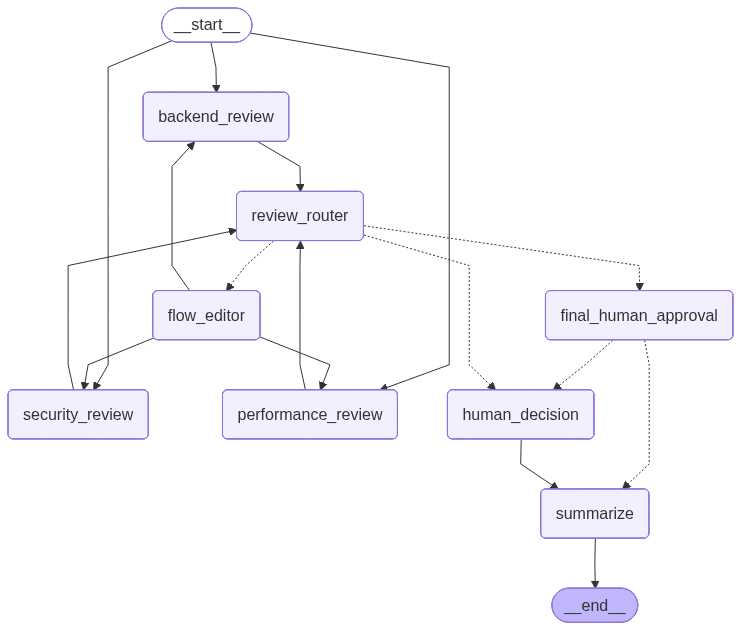

In [9]:
display_graph(graph)

In [10]:
def execute_workflow(user_request: str, thread_id: str | None = None) -> dict:
    thread_id = thread_id or f'workflow-{uuid4()}'
    config = {'configurable': {'thread_id': thread_id}}
    initial_state: WorkflowState = {
        'flow_history': [user_request],
        'review_results': [],
        'loop_count': 0,
        'final_output': '',
    }
    graph.invoke(initial_state, config=config)
    snapshot = graph.get_state(config)
    return {'config': config, 'snapshot': snapshot}

In [11]:
EXAMPLE_1_THREAD_BASE = 'example-1-blog-posts'
EXAMPLE_1_THREAD_ID = f'{EXAMPLE_1_THREAD_BASE}-{uuid4().hex[:8]}'
EXAMPLE_2_THREAD_ID = 'example-2-orders-payments'
EXAMPLE_3_THREAD_ID = 'example-3-chat-notifications'
EXAMPLE_4_THREAD_ID = 'example-4-video-pipeline'
EXAMPLE_5_THREAD_ID = 'example-5-iot-telemetry'

EXAMPLE_1_FLOW = 'Client sends request to Posts service, Posts writes to DB and emits an event to a broker, consumers update search index and send notifications.'
EXAMPLE_2_FLOW = 'Order service creates order, Payment service authorizes card, Inventory reserves stock, Shipping prepares fulfillment.'
EXAMPLE_3_FLOW = 'Chat API stores message, publishes event, fan-out service delivers to online users and queues offline notifications.'
EXAMPLE_4_FLOW = 'Upload API stores raw video, transcoding workers process variants, metadata service updates catalog, CDN serves playback.'
EXAMPLE_5_FLOW = 'IoT gateway ingests telemetry, stream processor validates data, time-series store persists metrics, alerting service triggers incidents.'



# EXAMPLE 1: BLOG POSTS EVENT FLOW
Run this section only. It executes the flow once and prints interrupts if they exist. The next cell provides continuation code for human interrupts.

In [12]:
config = {'configurable': {'thread_id': EXAMPLE_1_THREAD_ID}}
initial_state: WorkflowState = {
    'flow_history': [EXAMPLE_1_FLOW],
    'review_results': [],
    'loop_count': 0,
    'final_output': '',
}
graph.invoke(initial_state, config=config)


2026-05-12T10:41:54.757Z --- [Backend] node is executing
2026-05-12T10:41:54.760Z --- [Performance] node is executing
2026-05-12T10:41:54.761Z --- [Security] node is executing
2026-05-12T10:42:04.557Z --- [Backend][Tool Call] web_search
2026-05-12T10:42:12.004Z --- [Performance][Tool Call] web_search
2026-05-12T10:42:12.005Z --- [Performance][Tool Call] web_search
2026-05-12T10:42:12.006Z --- [Performance][Tool Call] web_search
2026-05-12T10:42:17.990Z --- [Security][Tool Call] web_search
2026-05-12T10:42:17.992Z --- [Security][Tool Call] web_search
2026-05-12T10:42:17.992Z --- [Security][Tool Call] web_search
2026-05-12T10:42:17.995Z --- [Review Router] Active major reviews: 3
2026-05-12T10:42:17.997Z --- [FlowEditor] node is executing


Deserializing unregistered type __main__.ReviewDecision from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ReviewDecision')]


2026-05-12T10:42:34.451Z --- [Backend] node is executing


Deserializing unregistered type __main__.ImprovementResult from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ImprovementResult')]


2026-05-12T10:42:34.453Z --- [Performance] node is executing
2026-05-12T10:42:34.453Z --- [Security] node is executing
2026-05-12T10:42:47.984Z --- [Security][Tool Call] web_search
2026-05-12T10:42:49.074Z --- [Performance][Tool Call] web_search
2026-05-12T10:42:53.389Z --- [Backend][Tool Call] web_search
2026-05-12T10:42:53.391Z --- [Review Router] Active major reviews: 3
2026-05-12T10:42:53.394Z --- [Human Decision] node is executing


{'flow_history': ['Client sends request to Posts service, Posts writes to DB and emits an event to a broker, consumers update search index and send notifications.',
  'Client → Posts. Within DB transaction write post + event to Outbox (versioned). Commit; reply. Outbox worker signs (JWS), publishes asynchronously to Kafka over mTLS+RBAC with retry/backoff; failures → DLQ. Consumers (partitioned autoscaled) verify signature/timestamp, validate schema, dedupe, bulk-index to ES, send notifications. Monitor outbox, lag, DLQ. Optional: Debezium CDC.'],
 'review_results': [{'Backend': {'reviewer': 'Backend',
    'status': 'reject',
    'comment': 'Reject: current flow risks lost events (DB write succeeds but publish fails), duplicate processing (at-least-once delivery), ordering and retry gaps, and missing DLQ/schema-versioning. These threaten correctness and data integrity; the outbox pattern is a known mitigation.',
    'recommendation': 'Implement a transactional outbox (persist event in 

In [13]:
EXAMPLE_1_MANUAL_FINAL_FLOW = """
Posts writes data and outbox atomically, relay publishes signed events, and idempotent consumers update index and notifications with retries, DLQ, and monitoring. All communucation happens
using TLS, following best practices according to the company policy
"""

resume_value = EXAMPLE_1_MANUAL_FINAL_FLOW
final_state = graph.invoke(Command(resume=resume_value), config=config)

2026-05-12T10:42:53.424Z --- [Human Decision] node is executing
2026-05-12T10:42:53.429Z --- [Summarization] node is executing
2026-05-12T10:43:29.514Z --- [Tool Call] youtube_search
2026-05-12T10:43:29.516Z --- [Tool Call] youtube_search
2026-05-12T10:43:29.517Z --- [Tool Call] youtube_search


In [15]:
final_state

{'flow_history': ['Client sends request to Posts service, Posts writes to DB and emits an event to a broker, consumers update search index and send notifications.',
  'Client → Posts. Within DB transaction write post + event to Outbox (versioned). Commit; reply. Outbox worker signs (JWS), publishes asynchronously to Kafka over mTLS+RBAC with retry/backoff; failures → DLQ. Consumers (partitioned autoscaled) verify signature/timestamp, validate schema, dedupe, bulk-index to ES, send notifications. Monitor outbox, lag, DLQ. Optional: Debezium CDC.',
  'Posts writes data and outbox atomically, relay publishes signed events, and idempotent consumers update index and notifications with retries, DLQ, and monitoring. All communucation happens\nusing TLS, following best practices according to the company policy'],
 'review_results': [{'Backend': {'reviewer': 'Backend',
    'status': 'reject',
    'comment': 'Reject: current flow risks lost events (DB write succeeds but publish fails), duplicate

# EXAMPLE 2: ORDERS AND PAYMENTS FLOW
Template only. Do not run in this pass.

# Example 2 template (not executed)
example_2_run = execute_workflow(EXAMPLE_2_FLOW, thread_id=EXAMPLE_2_THREAD_ID)
print_interrupts(example_2_run['snapshot'].interrupts)

# Optional continuation template
if example_2_run['snapshot'].interrupts:
    example_2_approved = resume_workflow(example_2_run['config'], {'action': 'approve'})
    print_interrupts(example_2_approved['snapshot'].interrupts)
    if not example_2_approved['snapshot'].interrupts:
        print(example_2_approved['snapshot'].values['final_output'])

# EXAMPLE 3: CHAT MESSAGES AND NOTIFICATIONS FLOW
Template only. Do not run in this pass.

# Example 3 template (not executed)
example_3_run = execute_workflow(EXAMPLE_3_FLOW, thread_id=EXAMPLE_3_THREAD_ID)
print_interrupts(example_3_run['snapshot'].interrupts)

# Optional continuation template
if example_3_run['snapshot'].interrupts:
    example_3_rejected = resume_workflow(example_3_run['config'], {'action': 'reject'})
    print_interrupts(example_3_rejected['snapshot'].interrupts)
    example_3_manual = resume_workflow(example_3_run['config'], {'final_flow': 'Manual final flow goes here.'})
    print_interrupts(example_3_manual['snapshot'].interrupts)
    if not example_3_manual['snapshot'].interrupts:
        print(example_3_manual['snapshot'].values['final_output'])

# EXAMPLE 4: VIDEO PROCESSING PIPELINE FLOW
Template only. Do not run in this pass.

### Example 4 run template
Use the next code cell when you want to execute this scenario.

# Example 4 template (not executed)
example_4_run = execute_workflow(EXAMPLE_4_FLOW, thread_id=EXAMPLE_4_THREAD_ID)
print_interrupts(example_4_run['snapshot'].interrupts)

# Optional continuation template
if example_4_run['snapshot'].interrupts:
    example_4_approved = resume_workflow(example_4_run['config'], {'action': 'approve'})
    print_interrupts(example_4_approved['snapshot'].interrupts)
    if not example_4_approved['snapshot'].interrupts:
        print(example_4_approved['snapshot'].values['final_output'])

# EXAMPLE 5: IOT TELEMETRY AND ALERTING FLOW
Template only. Do not run in this pass.

# Example 5 template (not executed)
example_5_run = execute_workflow(EXAMPLE_5_FLOW, thread_id=EXAMPLE_5_THREAD_ID)
print_interrupts(example_5_run['snapshot'].interrupts)

# Optional continuation template
if example_5_run['snapshot'].interrupts:
    example_5_rejected = resume_workflow(example_5_run['config'], {'action': 'reject'})
    print_interrupts(example_5_rejected['snapshot'].interrupts)
    example_5_manual = resume_workflow(example_5_run['config'], {'final_flow': 'Manual final flow goes here.'})
    print_interrupts(example_5_manual['snapshot'].interrupts)
    if not example_5_manual['snapshot'].interrupts:
        print(example_5_manual['snapshot'].values['final_output'])